## Notebook 01 — Circuit Building

---
In this notebook, we build and visually inspect the quantum circuits for three foundational oracle-based algorithms:

1. **Deutsch-Jozsa (DJ)** — Determines if a function is constant or balanced
2. **Bernstein-Vazirani (BV)** — Recovers a hidden bitstring
3. **Simon's Algorithm** — Finds the hidden period of a 2-to-1 mapping


## 1.1 Imports and Setup

In [1]:
import sys
import os

# Add project root to Python path so we can import from src/
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import pandas as pd
from qiskit import transpile
from qiskit_aer import AerSimulator

# Our project modules
from src.circuits import (
    build_dj_oracle,
    build_dj_circuit,
    build_bv_circuit,
    build_simon_circuit,
    check_simon_success,
    generate_secret_strings,
    generate_all_circuit_configs,
    get_circuit_stats,
)

print('All imports successful!')
print(f'Project root: {project_root}')

All imports successful!
Project root: G:\Quantum


#### Helper Function
A utility to run a circuit on the ideal (noiseless) Aer simulator and return measurement counts.

In [2]:
def run_ideal(circuit, shots=4096):
    """Run a circuit on the ideal Aer simulator."""
    sim = AerSimulator()
    transpiled = transpile(circuit, sim)
    result = sim.run(transpiled, shots=shots).result()
    return result.get_counts()

---

## 1.2 Deutsch-Jozsa Algorithm


The Deutsch-Jozsa algorithm determines whether a black-box function $f: \{0,1\}^n \rightarrow \{0,1\}$ is **constant** (same output for all inputs) or **balanced** (outputs 0 for exactly half, 1 for the other half).

**Circuit steps:**
1. Initialize ancilla qubit to $|1\rangle$
2. Apply Hadamard gates to all qubits
3. Apply the oracle $U_f$
4. Apply Hadamard gates to input qubits
5. Measure input qubits

**Expected output:**
- Constant oracle → measure $|00\ldots0\rangle$
- Balanced oracle → measure any non-zero bitstring

### 1.2.1 Constant Oracle (f(x) = 0 for all x)

DJ Circuit (Constant-0, n=3):
Total qubits: 4 (3 input + 1 ancilla)
Classical bits: 3



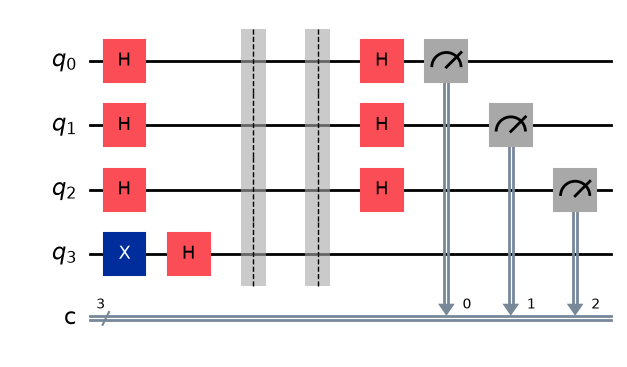

In [3]:
# Build a constant-0 oracle for 3 qubits
n = 3
oracle_const = build_dj_oracle(n, 'constant_0')
circuit_const = build_dj_circuit(n, oracle_const)

print(f'DJ Circuit (Constant-0, n={n}):')
print(f'Total qubits: {circuit_const.num_qubits} ({n} input + 1 ancilla)')
print(f'Classical bits: {circuit_const.num_clbits}')
print()
circuit_const.draw(output='mpl', style='iqp', fold=40)

### 1.2.2 Balanced Oracle

DJ Circuit (Balanced, n=3):


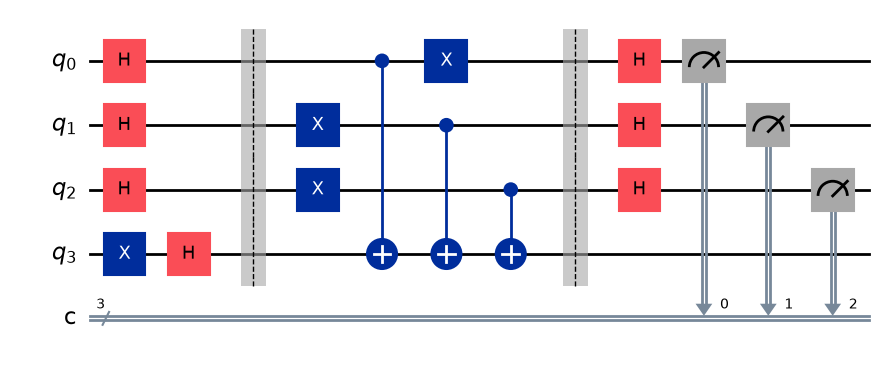

In [5]:
# Build a balanced oracle for 3 qubits
oracle_bal = build_dj_oracle(n, 'balanced', seed=42)
circuit_bal = build_dj_circuit(n, oracle_bal)

print(f'DJ Circuit (Balanced, n={n}):')
circuit_bal.draw(output='mpl', style='iqp', fold=40)

---

## 1.3 Bernstein-Vazirani Algorithm

The Bernstein-Vazirani algorithm recovers a hidden bitstring $s \in \{0,1\}^n$ from an oracle that computes $f(x) = s \cdot x \pmod{2}$ (bitwise inner product).

**Circuit steps:**
1. Initialize ancilla to $|1\rangle$
2. Apply Hadamard gates to all qubits
3. Apply the oracle (CNOT from each qubit where $s_i = 1$ to the ancilla)
4. Apply Hadamard gates to input qubits
5. Measure — the result IS the secret string $s$

**Key property:** BV recovers $s$ in a **single query**, compared to $n$ classical queries.

BV Circuit (secret="101", n=3):
Total qubits: 4 (3 input + 1 ancilla)



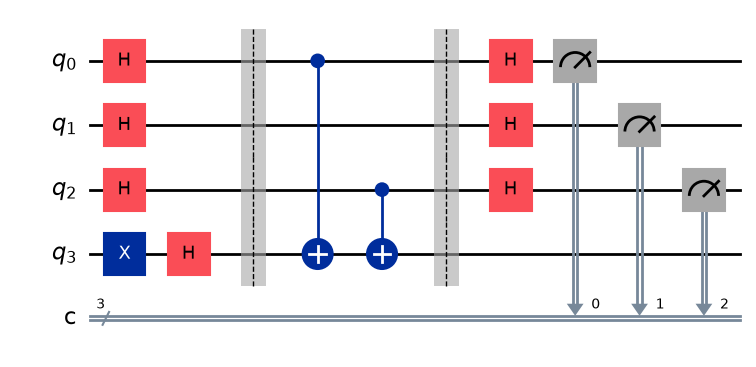

In [7]:
# Build BV circuit with secret string '101'
secret = '101'
n = len(secret)
circuit_bv = build_bv_circuit(n, secret)

print(f'BV Circuit (secret="{secret}", n={n}):')
print(f'Total qubits: {circuit_bv.num_qubits} ({n} input + 1 ancilla)')
print()
circuit_bv.draw(output='mpl', style='iqp', fold=40)

---

## 1.4 Simon's Algorithm

Simon's algorithm finds a hidden bitstring $s$ such that for a function $f$:
$$f(x) = f(y) \iff x \oplus y \in \{0^n, s\}$$

This means $f$ is either 1-to-1 (if $s = 0^n$) or 2-to-1.

**Circuit steps:**
1. Apply Hadamard to input register
2. Apply the oracle
3. Apply Hadamard to input register
4. Measure input register

Each measurement produces a bitstring $z$ satisfying $z \cdot s = 0 \pmod{2}$. Multiple runs + classical post-processing determine $s$.


Simon's Circuit (period="10", n=2):
Total qubits: 4 (2 input + 2 output)



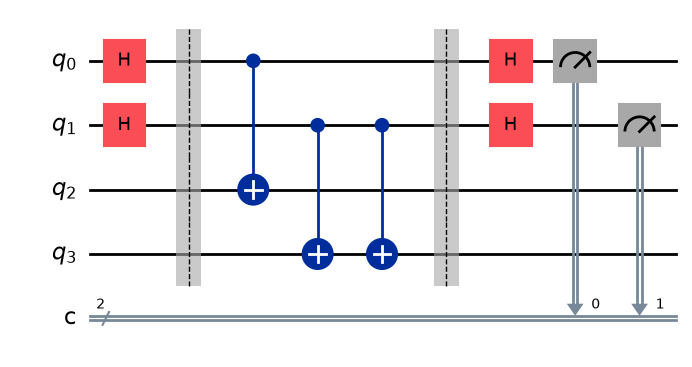

In [10]:
# Build Simon's circuit with secret period '10'
secret = '10'
n = len(secret)
circuit_simon = build_simon_circuit(n, secret)

print(f"Simon's Circuit (period=\"{secret}\", n={n}):")
print(f'Total qubits: {circuit_simon.num_qubits} ({n} input + {n} output)')
print()
circuit_simon.draw(output='mpl', style='iqp', fold=40)